# DGA Signal Investigation (V2)

Controlled diagnostic stage. V1 remains unchanged; XGBoost uses the exact V1 configuration with no tuning. Asset and time are diagnostics only, not model features. The notebook examines label relationships, class overlap, assets, time, repeated CV, a repeated permutation control, unseen-asset and chronological checks, then an all-pass tuning gate.

Installing missing V2 dependencies: ['matplotlib', 'seaborn', 'scipy', 'scikit-learn', 'openpyxl', 'xgboost']


Rows=300; time range: 2025-01-01 00:00:00 to 2025-01-13 11:00:00


,count,proportion
fault_by_rogers,,
Non-determinable,63,0.210000
Normal,87,0.290000
Partial Discharge,76,0.253333
Thermal Fault,74,0.246667



1. Synthetic target-generation / label relationship checks

status by target


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
status,,,,
Abnormal,0.21,0.304,0.243,0.243
Normal,0.21,0.269,0.269,0.252


...

fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
abnormal,,,,
False,0.21,0.269,0.269,0.252
True,0.21,0.304,0.243,0.243



triggers by target


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
triggers,,,,
<missing>,0.21,0.269,0.269,0.252
C2H4 > 60,0.21,0.304,0.243,0.243


,feature,Kruskal_H,p_unadjusted,epsilon_squared,mutual_information
9,R_C2H4_C2H6,4.7522,0.1909,0.0059,0.0000
4,CH4,4.6635,0.1982,0.0056,0.0392
3,C2H6,3.7225,0.2930,0.0024,0.0000
0,H2,1.1182,0.7727,0.0000,0.0217
1,C2H2,2.2018,0.5316,0.0000,0.0000
2,C2H4,1.3640,0.7140,0.0000,0.0516
5,CO,1.3572,0.7156,0.0000,0.0050
6,CO2,1.6659,0.6445,0.0000,0.0000
7,R_C2H2_C2H4,2.2344,0.5252,0.0000,0.0000
8,R_CH4_H2,1.5524,0.6702,0.0000,0.0000


The data cannot prove its hidden generator. Provider question: which DGA fields/rules/thresholds/transformations/randomisation generated fault_by_rogers, and were labels independent of DGA?

2. Class separability and feature distributions


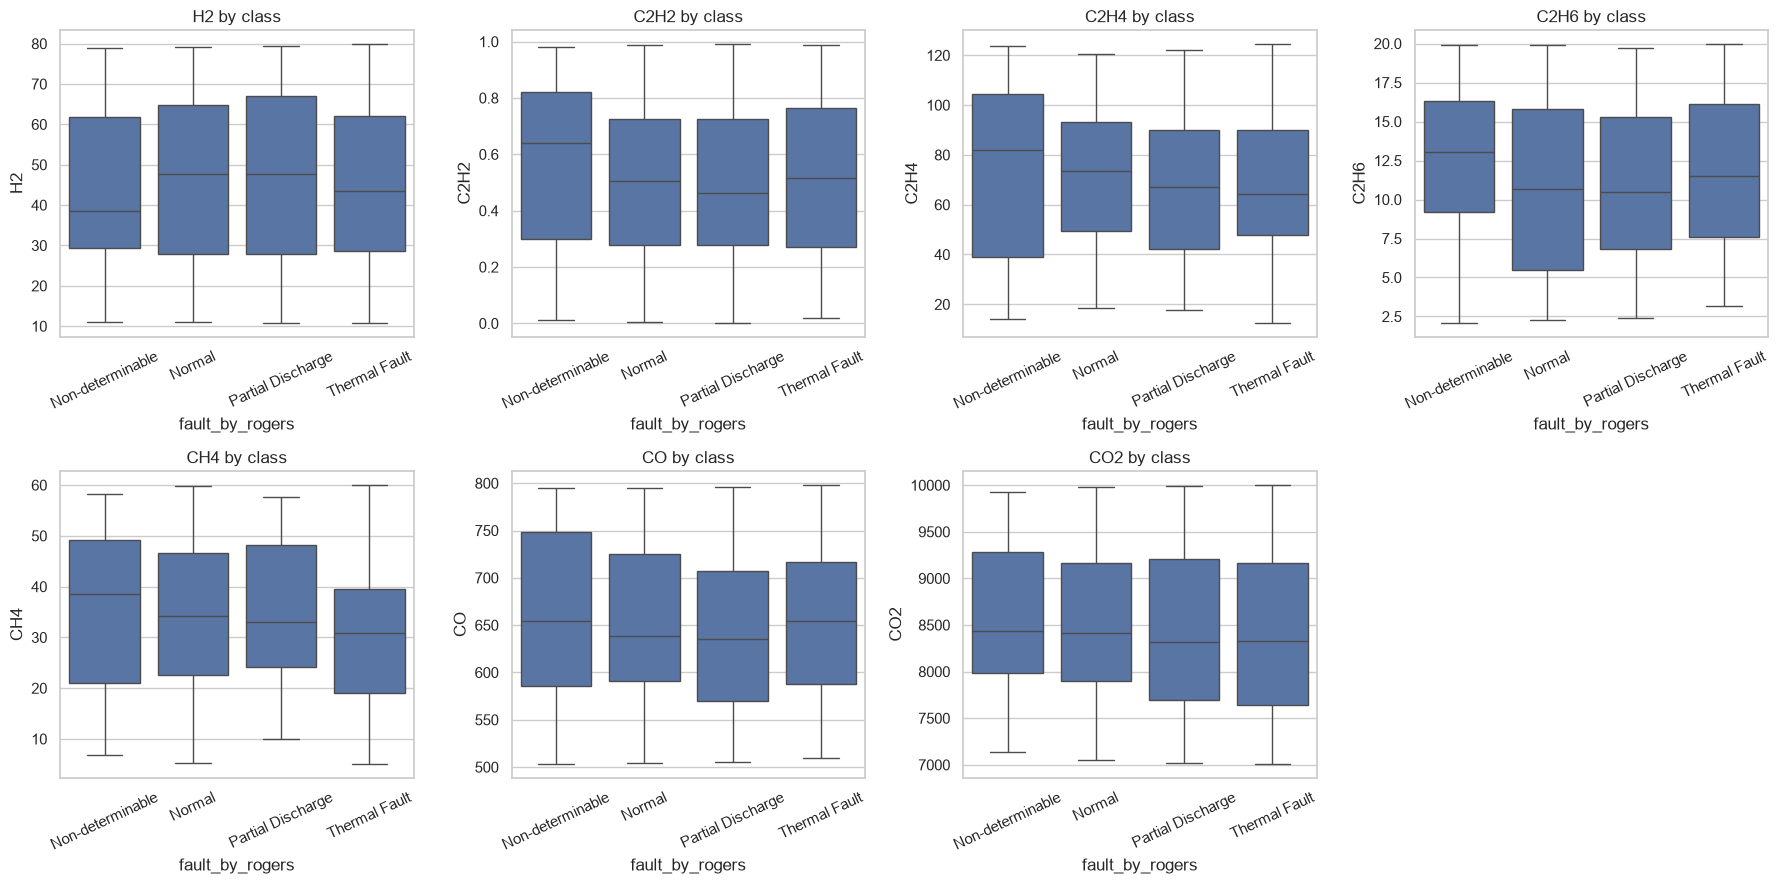

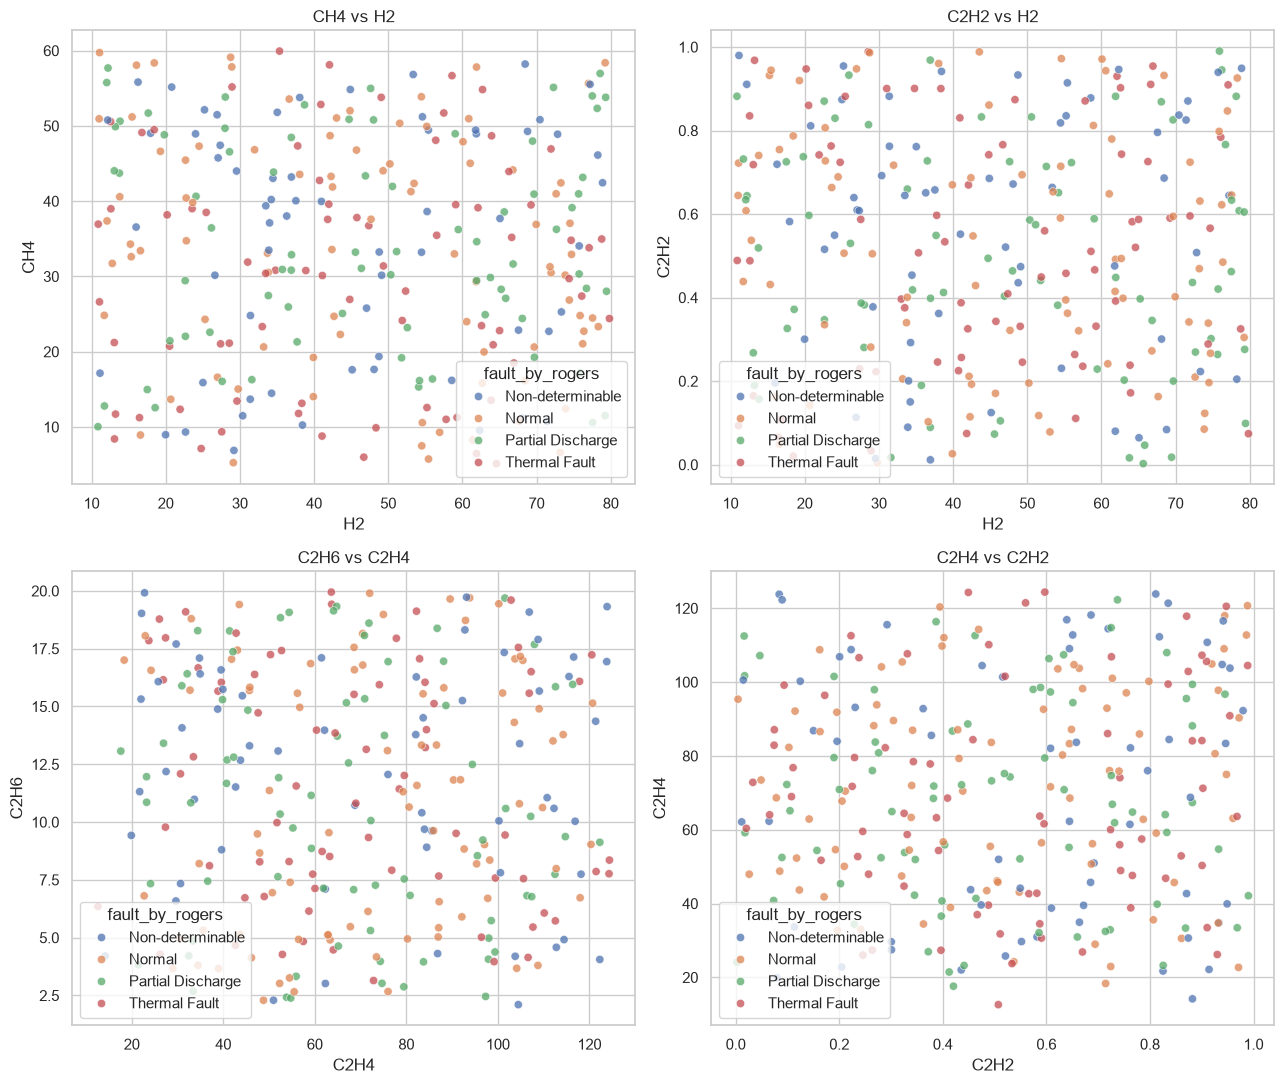

PCA PC1+PC2 variance explained: 42.4%


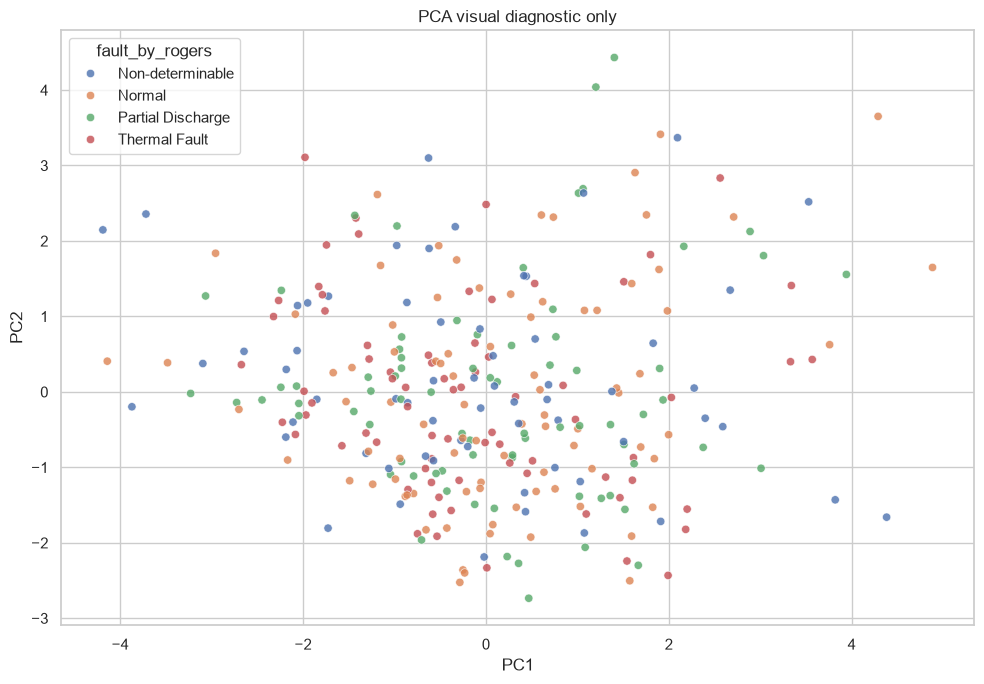


3. Asset-target relationship


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
asset,,,,
TX_A,19,32,22,26
TX_B,21,30,19,26
TX_C,23,25,35,22


chi-square p=0.3338; Cramer's V=0.107


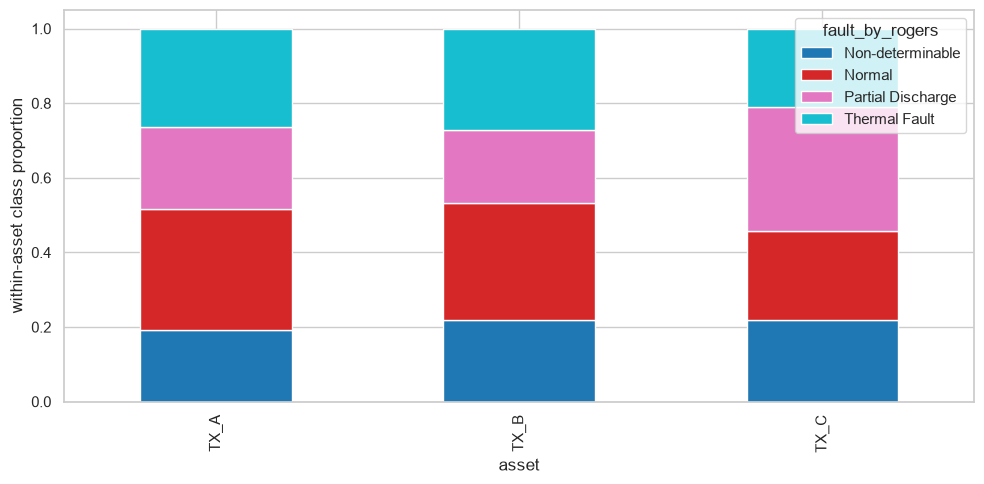


4. Temporal structure


,count,min,max
asset,,,
TX_A,99,2025-01-01 00:00:00,2025-01-13 10:00:00
TX_B,96,2025-01-01 01:00:00,2025-01-13 09:00:00
TX_C,105,2025-01-01 02:00:00,2025-01-13 11:00:00


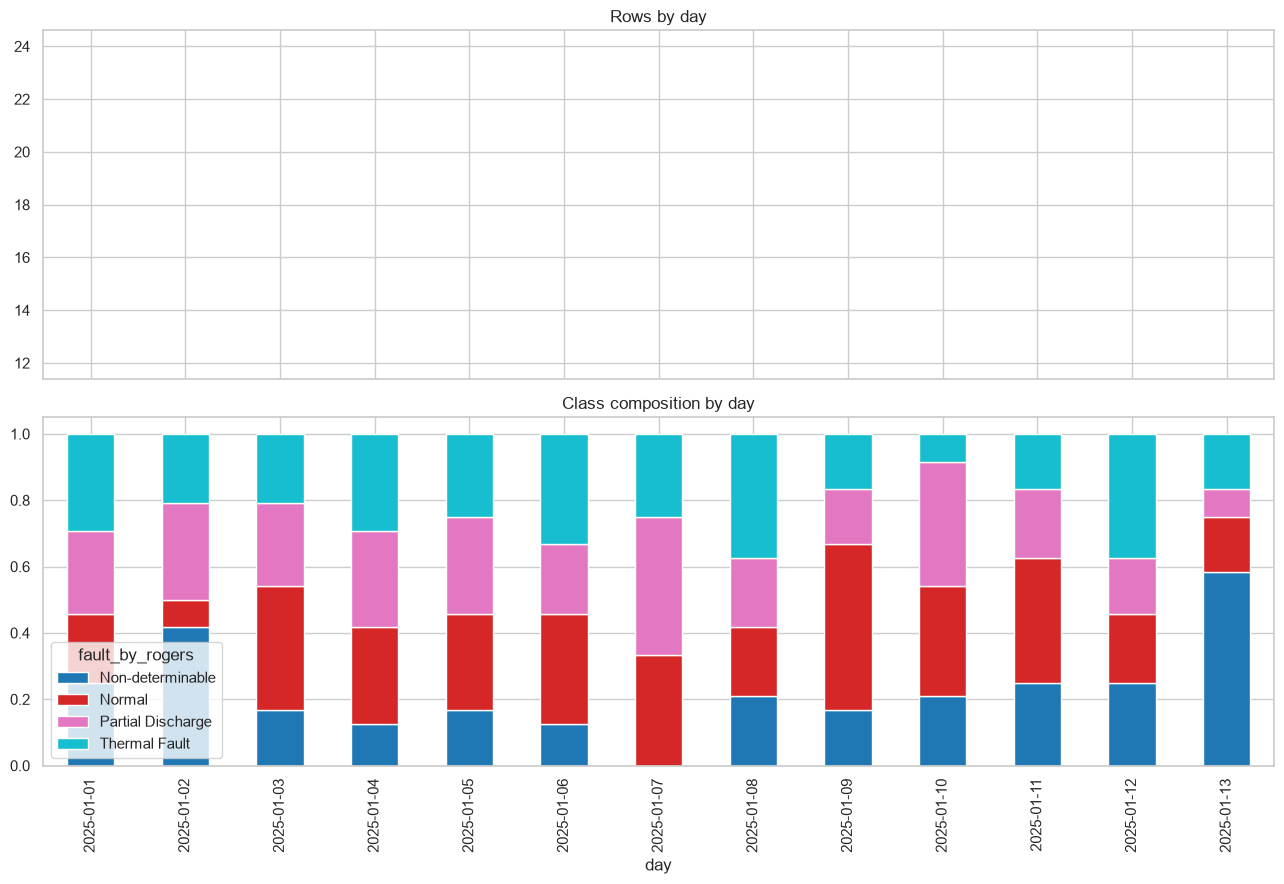

Chronologically adjacent rows from same asset: 34.8%

5. Repeated stratified CV: 5 folds x 5 repeats


,model,validation_macro_f1,fold_sd,train_macro_f1,gap,accuracy,balanced_accuracy
0,Fixed XGBoost,0.2627,0.0392,0.9868,0.7241,0.2693,0.2662
1,Majority baseline,0.1124,0.0025,0.1124,0.0000,0.2900,0.2500


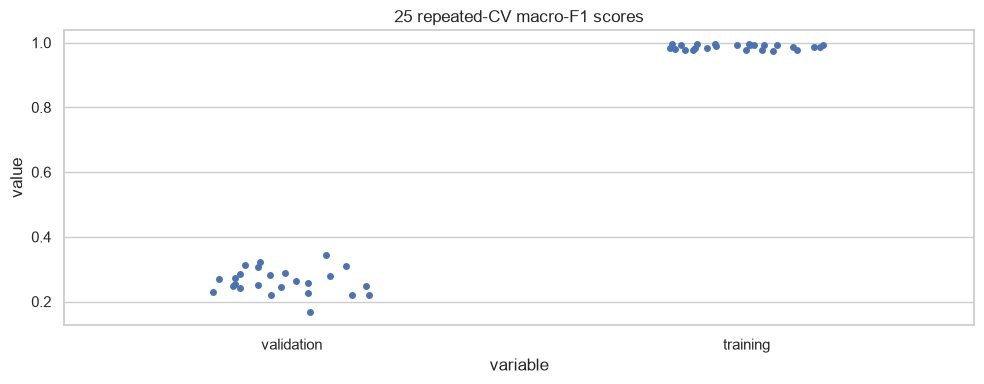


6. Repeated permutation-label control: 100 null experiments


,real_mean,null_mean,null_sd,null_95th_pct,empirical_one_sided_p
0,0.2627,0.2462,0.0265,0.2882,0.2772


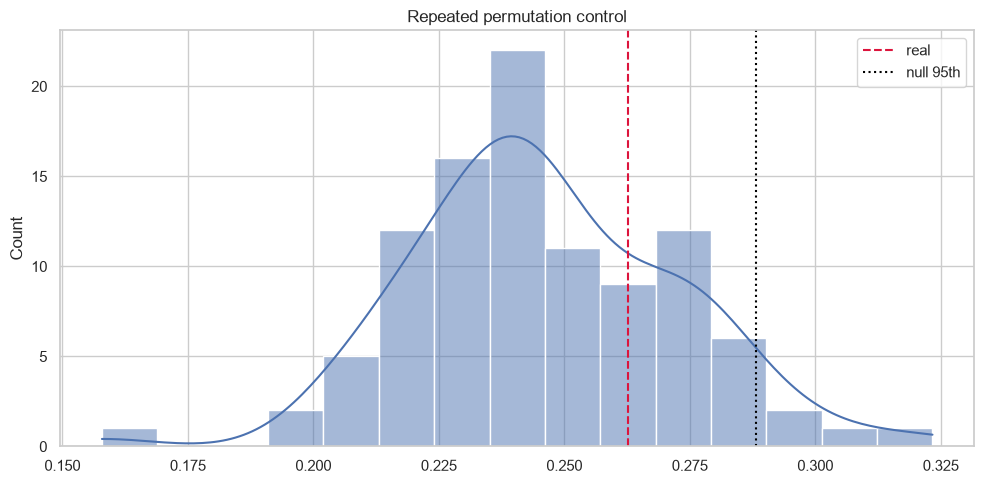


7. Robustness checks


,representation,repeated_cv_macro_f1,gap
1,Raw + ratios,0.2627,0.7241
0,Raw DGA,0.2574,0.7187
2,Ratios only,0.2107,0.6487


Leave-one-asset-out


,held_out_asset,train_n,test_n,train_macro_f1,test_macro_f1,majority_test_macro_f1
0,TX_A,201,99,0.9949,0.2630,0.1221
1,TX_B,204,96,0.9912,0.1964,0.1190
2,TX_C,195,105,0.9898,0.2108,0.0962


Chronological 70/30 holdout


,train_n,test_n,train_macro_f1,test_macro_f1,majority_test_macro_f1,test_accuracy,test_balanced_accuracy
0,210,90,0.9902,0.2344,0.1154,0.2889,0.2825



8. XGBoost tuning gate — all conditions must pass


,condition,pass,evidence
0,Real exceeds permutation,False,real=0.2627; null p95=0.2882; p=0.2772
1,Meaningfully exceeds majority,True,margin=0.1503; threshold=.0500
2,Some representation exceeds null,False,best=Raw + ratios: 0.2627
3,No substantial memorisation,False,gap=0.7241; threshold <=.2000
4,Asset and time robustness beat baselines,True,asset=0.2234/0.1124; time=0.2344/0.1154


V2 CONCLUSION
INVESTIGATE — weak/unstable evidence; review target construction, overlap, asset and temporal effects before tuning.


In [1]:
%run v2_dga_signal_analysis.py